In [1]:
# Loading relevant libraries.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# Ignoring warnings.
import warnings

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [2]:
# Loading the dataset.
studygroup = pd.read_csv('sg_studentdata.csv')

# Display basic information
print(studygroup.info())
print(studygroup.describe())

# Check for missing values
print(studygroup.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71754 entries, 0 to 71753
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Centre             71754 non-null  object 
 1   Programme          71754 non-null  object 
 2   Area               71754 non-null  object 
 3   Region             71754 non-null  object 
 4   Sub Region         70946 non-null  object 
 5   Country            71754 non-null  object 
 6   Branch URN         71754 non-null  object 
 7   Group URN          71754 non-null  object 
 8   Lead Source        71754 non-null  object 
 9   Student ID         71754 non-null  int64  
 10  Booking ID         71754 non-null  int64  
 11  Nationality        71754 non-null  object 
 12  IntakeYear         71754 non-null  int64  
 13  IntakeQuarter      71754 non-null  int64  
 14  Application Date   71754 non-null  object 
 15  Offered Date       51892 non-null  object 
 16  Confirmation Date  643

In [3]:
# View the first few rows of the dataset.
studygroup.head()

,Centre,Programme,Area,Region,Sub Region,Country,Branch URN,Group URN,Lead Source,Student ID,Booking ID,Nationality,IntakeYear,IntakeQuarter,Application Date,Offered Date,Confirmation Date,Arrived Date,Cancellation Date,Completed,Progressed,Registered,Tuition Fees,Net Value,Discount,Discount Type
0,Cardiff,Diploma,ANZ & N Asia,ANZ,Australia,Aus - VIC,A31552,A31552,Standard Agent Booking,2864317,44220215,Bangladeshi,2024,1,04-Oct-23,NaN,NaN,NaN,05/10/2023,NaN,NaN,NaN,19500.0,19500.0,0.0,NaN
1,Cardiff,Diploma,ANZ & N Asia,Hong Kong,Hong Kong,Hong Kong,A15382,A29520,Standard Agent Booking,2853769,44168427,Hong Kong Chinese,2024,1,21-Nov-23,21-Nov-23,NaN,NaN,01/03/2024,NaN,NaN,NaN,20000.0,20000.0,0.0,NaN
2,Cardiff,Diploma,ANZ & N Asia,Hong Kong,Hong Kong,Hong Kong,A15382,A29520,Standard Agent Booking,2863293,44498903,Hong Kong Chinese,2024,1,29-Sep-23,29-Nov-23,NaN,NaN,01/03/2024,NaN,NaN,NaN,19500.0,19500.0,0.0,NaN
3,Cardiff,Diploma,ANZ & N Asia,Hong Kong,Hong Kong,Hong Kong,A7608,A7608,Standard Agent Booking,2854643,44173342,Hong Kong Chinese,2024,1,25-Aug-23,NaN,NaN,NaN,30/08/2023,NaN,NaN,NaN,19500.0,19500.0,0.0,NaN
4,Cardiff,Diploma,ANZ & N Asia,Hong Kong,Hong Kong,Hong Kong,D1107,D1107,Standard Agent Booking,2871048,44251632,Chinese,2024,2,06-Dec-23,06-Dec-23,NaN,NaN,24/05/2024,NaN,NaN,NaN,24850.0,24850.0,0.0,NaN


In [4]:
# Filter the dataset to include only students who have completed the course
completed_students = studygroup[studygroup['Completed'].notnull()]

# Convert the date columns to datetime format
date_columns = ['Application Date', 'Offered Date', 'Confirmation Date', 'Arrived Date', 'Cancellation Date', 'Completed']
for col in date_columns:
    completed_students[col] = pd.to_datetime(completed_students[col], errors='coerce')

# Create a new column to indicate whether a student received a discount or not
completed_students['Received Discount'] = completed_students['Discount'] > 0

# Replace the qcut/cut code with this simpler version:
def get_discount_group(x):
    if x == 0:
        return 'No Discount'
    elif x <= 1000:
        return 'Low'
    elif x <= 3000:
        return 'Medium' 
    else:
        return 'High'

# Create the discount groups using custom function
completed_students['Discount Group'] = completed_students['Discount'].apply(get_discount_group)

# For visualization purposes, create ordered categories
completed_students['Discount Group'] = pd.Categorical(
    completed_students['Discount Group'],
    categories=['No Discount', 'Low', 'Medium', 'High'],
    ordered=True
)


C:\Users\Emmanuel Wagaba\AppData\Local\Temp\ipykernel_34320\1824206417.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  completed_students[col] = pd.to_datetime(completed_students[col], errors='coerce')
C:\Users\Emmanuel Wagaba\AppData\Local\Temp\ipykernel_34320\1824206417.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  completed_students[col] = pd.to_datetime(completed_students[col], errors='coerce')
C:\Users\Emmanuel Wagaba\AppData\Local\Temp\ipykernel_34320\1824206417.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing

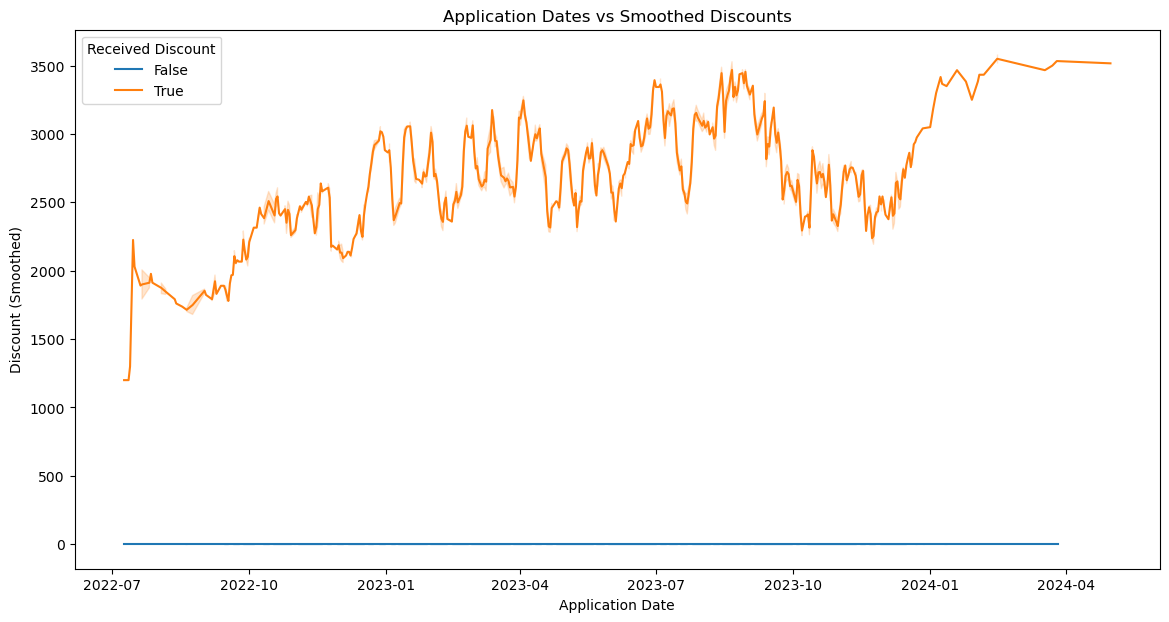

In [5]:
# Ensure the data is sorted by 'Application Date'
completed_students = completed_students.sort_values('Application Date')

# Compute a rolling mean of the 'Discount' for each group of 'Received Discount'
completed_students['Discount_smooth'] = completed_students.groupby('Received Discount')['Discount'] \
    .transform(lambda x: x.rolling(window=30, min_periods=1).mean())

plt.figure(figsize=(14, 7))
sns.lineplot(data=completed_students, x='Application Date', y='Discount_smooth', hue='Received Discount')
plt.title('Application Dates vs Smoothed Discounts')
plt.xlabel('Application Date')
plt.ylabel('Discount (Smoothed)')
plt.legend(title='Received Discount')
plt.show()


In [6]:
# Perform linear regression to analyze the relationship between application dates and discounts
completed_students['Application Date Ordinal'] = completed_students['Application Date'].map(pd.Timestamp.toordinal)
X = completed_students[['Application Date Ordinal']]
y = completed_students['Discount']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)
print(f'R^2 Score: {model.score(X_test, y_test)}')
print(f'Coefficients: {model.coef_}')
print(f'Intercept: {model.intercept_}')

R^2 Score: 0.006006977156142401
Coefficients: [0.58319248]
Intercept: -429639.22443647176


In [10]:
# New cell for time series analysis
# Filter for completed students (excluding terminated)
completed_df = studygroup[studygroup['Completed'].notna()]



# Convert dates to datetime
completed_df['Application Date'] = pd.to_datetime(completed_df['Application Date'])

# Create discount category
completed_df['Has Discount'] = completed_df['Discount'].apply(lambda x: 'Yes' if x > 0 else 'No')

# Get the bins and bin edges
_, bin_edges = pd.qcut(
    completed_df['Discount'], 
    q=4, 
    retbins=True, 
    duplicates='drop'
)
n_bins = len(bin_edges) - 1  # number of bins

# Adjust the labels list to have the correct number of labels
base_labels = ['Low', 'Medium', 'High', 'Very High']
labels = base_labels[:n_bins]

# Now create the discount groups with the adjusted labels list
completed_df['Discount_Group'] = pd.qcut(
    completed_df['Discount'], 
    q=4, 
    labels=labels, 
    duplicates='drop'
)


C:\Users\Emmanuel Wagaba\AppData\Local\Temp\ipykernel_34320\1359661137.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  completed_df['Application Date'] = pd.to_datetime(completed_df['Application Date'])
C:\Users\Emmanuel Wagaba\AppData\Local\Temp\ipykernel_34320\1359661137.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  completed_df['Application Date'] = pd.to_datetime(completed_df['Application Date'])
C:\Users\Emmanuel Wagaba\AppData\Local\Temp\ipykernel_34320\1359661137.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_i

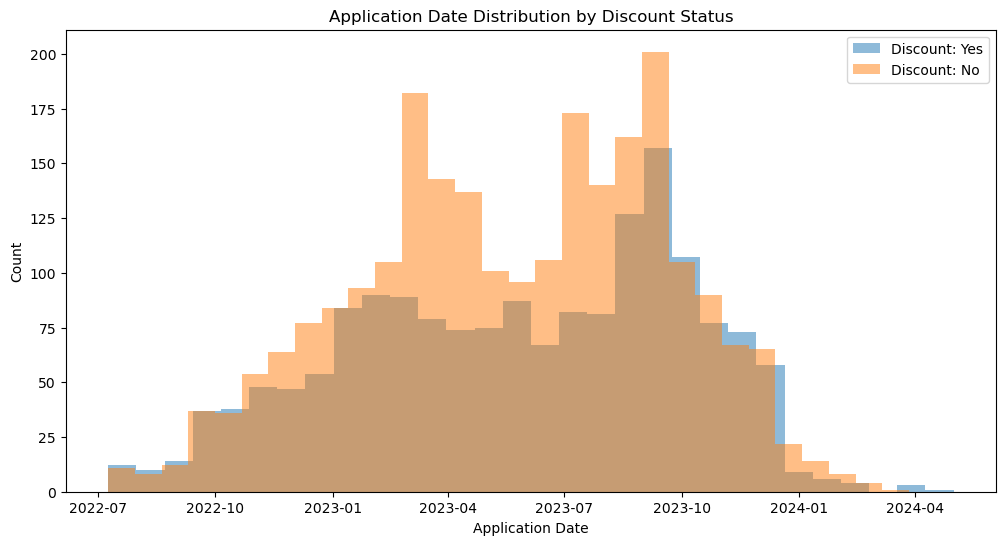

In [11]:
# Plot applications over time by discount status
plt.figure(figsize=(12,6))
for discount_status in ['Yes', 'No']:
    temp_df = completed_df[completed_df['Has Discount'] == discount_status]
    plt.hist(temp_df['Application Date'], bins=30, alpha=0.5, label=f'Discount: {discount_status}')

plt.title('Application Date Distribution by Discount Status')
plt.xlabel('Application Date')
plt.ylabel('Count')
plt.legend()
plt.show()


In [12]:
# Prepare data for linear regression
# Convert dates to numeric values for regression
completed_df['Days_Since_Start'] = (completed_df['Application Date'] - completed_df['Application Date'].min()).dt.days

# Create training and test sets
X = completed_df[['Days_Since_Start']]
y = completed_df['Discount']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit linear regression model
model = LinearRegression()
model.fit(X_train, y_train)


C:\Users\Emmanuel Wagaba\AppData\Local\Temp\ipykernel_34320\3653445315.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  completed_df['Days_Since_Start'] = (completed_df['Application Date'] - completed_df['Application Date'].min()).dt.days


LinearRegression()

In [13]:
# Print model results
print("\nLinear Regression Results:")
print(f"R-squared score: {model.score(X_test, y_test):.4f}")
print(f"Coefficient: {model.coef_[0]:.4f}")
print(f"Intercept: {model.intercept_:.4f}")



Linear Regression Results:
R-squared score: 0.0060
Coefficient: 0.5550
Intercept: 962.3503


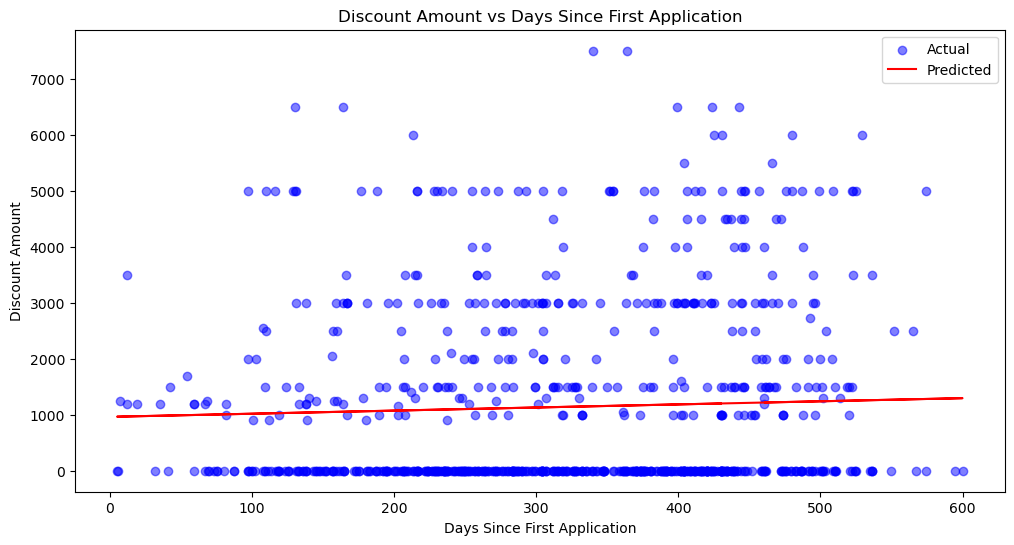

In [14]:
# Plot regression line
plt.figure(figsize=(12,6))
plt.scatter(X_test, y_test, color='blue', alpha=0.5, label='Actual')
plt.plot(X_test, model.predict(X_test), color='red', label='Predicted')
plt.title('Discount Amount vs Days Since First Application')
plt.xlabel('Days Since First Application')
plt.ylabel('Discount Amount')
plt.legend()
plt.show()


In [15]:
# Summary statistics by discount group
print("\nSummary Statistics by Discount Group:")
print(completed_df.groupby('Discount_Group')['Discount'].describe())


Summary Statistics by Discount Group:
                 count         mean          std     min     25%     50%  \
Discount_Group                                                             
Low             3104.0   315.678264   601.925543     0.0     0.0     0.0   
Medium           984.0  3746.670732  1103.063783  2050.0  3000.0  3500.0   

                   75%     max  
Discount_Group                  
Low                0.0  2000.0  
Medium          5000.0  7500.0  


C:\Users\Emmanuel Wagaba\AppData\Local\Temp\ipykernel_34320\4048400704.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(completed_df.groupby('Discount_Group')['Discount'].describe())


In [ ]:
s